## 1. Track Information Table (tracks.csv)

This is the main table containing identification information and the musical features of each track.

| Column Name | Meaning | Notes |
| :--- | :--- | :--- |
| **id** | Unique identifier for the track | Provided by Spotify |
| **name** | Track name | |
| **popularity** | Popularity score (0 - 100) | Based on total plays and the recency of the track |
| **duration_ms** | Track duration | Measured in milliseconds (ms) |
| **explicit** | Explicit content | 1: Yes (True), 0: No (False) |
| **artists** | Artist name(s) | |
| **id_artists** | Artist ID(s) | Used to link with the `artists.csv` table |
| **release_date** | Release date | Format YYYY-MM-DD or YYYY |

---

## 2. Artist Information Table (artists.csv)

This table provides detailed information about the artist's influence and musical genres.

| Column Name | Meaning | Notes |
| :--- | :--- | :--- |
| **id** | Artist's unique identifier | Primary key for joining |
| **followers** | Total number of followers | |
| **genres** | List of musical genres | Stored as an array (List) |
| **name** | Artist name | |
| **popularity** | Artist's popularity | Score from 0 - 100 |

---

## 3. Audio Features Explanation

These are metrics analyzed from sound waves by Spotify's AI algorithms, highly crucial for trend analysis or building recommendation systems.

| Feature | Value Range | Detailed Explanation |
| :--- | :--- | :--- |
| **Danceability** | 0.0 - 1.0 | **Suitability for dancing:** Based on tempo, rhythm stability, and beat strength. |
| **Energy** | 0.0 - 1.0 | **Energy level:** Intensity and activity (fast, loud, strong). |
| **Key** | -1 - 11 | **Musical key:** 0 = C, 1 = C♯, 2 = D,... |
| **Loudness** | -60 - 0 dB | **Volume:** The overall average loudness of a track. |
| **Mode** | 0 - 1 | **Modality:** 1 is Major, 0 is Minor. |
| **Speechiness** | 0.0 - 1.0 | **Spoken words:** Detects the presence of spoken words (Rap/Talk). |
| **Acousticness** | 0.0 - 1.0 | **Acoustic feel:** Probability that the track is acoustic (non-electronic instruments). |
| **Instrumentalness**| 0.0 - 1.0 | **Vocal absence:** The closer to 1.0, the fewer or no vocals the track contains. |
| **Liveness** | 0.0 - 1.0 | **Live presence:** Probability that the track was performed live with an audience. |
| **Valence** | 0.0 - 1.0 | **Musical positiveness:** High = happy/cheerful/euphoric, Low = sad/depressed/angry. |
| **Tempo** | BPM | **Pace:** The overall estimated tempo of a track (Beats Per Minute). |

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
df_tracks = pd.read_csv('data/tracks.csv')
df_tracks.head()

,id,name,popularity,duration_ms,explicit,artists,id_artists,release_date,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,35iwgR4jXetI318WEWsa1Q,Carve,6,126903,0,['Uli'],['45tIt06XoI0Iio4LBEVpls'],1922-02-22,0.645,0.4450,0,-13.338,1,0.4510,0.674,0.7440,0.151,0.127,104.851,3
1,021ht4sdgPcrDgSk7JTbKY,Capítulo 2.16 - Banquero Anarquista,0,98200,0,['Fernando Pessoa'],['14jtPCOoNZwquk5wd9DxrY'],1922-06-01,0.695,0.2630,0,-22.136,1,0.9570,0.797,0.0000,0.148,0.655,102.009,1
2,07A5yehtSnoedViJAZkNnc,Vivo para Quererte - Remasterizado,0,181640,0,['Ignacio Corsini'],['5LiOoJbxVSAMkBS2fUm3X2'],1922-03-21,0.434,0.1770,1,-21.180,1,0.0512,0.994,0.0218,0.212,0.457,130.418,5
3,08FmqUhxtyLTn6pAh6bk45,El Prisionero - Remasterizado,0,176907,0,['Ignacio Corsini'],['5LiOoJbxVSAMkBS2fUm3X2'],1922-03-21,0.321,0.0946,7,-27.961,1,0.0504,0.995,0.9180,0.104,0.397,169.980,3
4,08y9GfoqCWfOGsKdwojr5e,Lady of the Evening,0,163080,0,['Dick Haymes'],['3BiJGZsyX9sJchTqcSA7Su'],1922,0.402,0.1580,3,-16.900,0,0.0390,0.989,0.1300,0.311,0.196,103.220,4


In [26]:
# null values

pd.isnull(df_tracks).sum()

id                   0
name                71
popularity           0
duration_ms          0
explicit             0
artists              0
id_artists           0
release_date         0
danceability         0
energy               0
key                  0
loudness             0
mode                 0
speechiness          0
acousticness         0
instrumentalness     0
liveness             0
valence              0
tempo                0
time_signature       0
dtype: int64

In [27]:
df_tracks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 586672 entries, 0 to 586671
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                586672 non-null  object 
 1   name              586601 non-null  object 
 2   popularity        586672 non-null  int64  
 3   duration_ms       586672 non-null  int64  
 4   explicit          586672 non-null  int64  
 5   artists           586672 non-null  object 
 6   id_artists        586672 non-null  object 
 7   release_date      586672 non-null  object 
 8   danceability      586672 non-null  float64
 9   energy            586672 non-null  float64
 10  key               586672 non-null  int64  
 11  loudness          586672 non-null  float64
 12  mode              586672 non-null  int64  
 13  speechiness       586672 non-null  float64
 14  acousticness      586672 non-null  float64
 15  instrumentalness  586672 non-null  float64
 16  liveness          58

In [28]:
sorted_df = df_tracks.sort_values('popularity', ascending=True).head(10)
sorted_df

,id,name,popularity,duration_ms,explicit,artists,id_artists,release_date,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
32,1HXdv1z9RlvrcUernyf0MY,The Dear Little Shamrock,0,191613,0,['Dick Haymes'],['3BiJGZsyX9sJchTqcSA7Su'],1922,0.347,0.197,10,-15.652,1,0.0504,0.991,0.000133,0.196,0.246,109.338,3
78,3XxlglpLYkpZIfU1c1C5e4,Pobre Cotorro - Remasterizado,0,159800,0,['Ignacio Corsini'],['5LiOoJbxVSAMkBS2fUm3X2'],1922-03-21,0.564,0.053,6,-25.041,0,0.1270,0.996,0.927000,0.117,0.407,140.216,4
77,3ROtnqCtqrMbaDkivZyV5n,Entrerriana - Remasterizado,0,183720,0,['Ignacio Corsini'],['5LiOoJbxVSAMkBS2fUm3X2'],1922-03-21,0.431,0.200,5,-23.557,0,0.0322,0.995,0.821000,0.139,0.543,108.650,3
76,3QkuxlHi5RXa2YBr6S52n3,Capítulo 2.9 - Banquero Anarquista,0,99900,0,['Fernando Pessoa'],['14jtPCOoNZwquk5wd9DxrY'],1922-06-01,0.768,0.232,7,-21.678,0,0.9620,0.593,0.000000,0.304,0.591,64.433,4
75,3FfL0WRdyrEFPlPvmqj2lJ,Capítulo 1.9 - Banquero Anarquista,0,106900,0,['Fernando Pessoa'],['14jtPCOoNZwquk5wd9DxrY'],1922-06-01,0.619,0.173,0,-23.130,1,0.9670,0.730,0.000000,0.145,0.653,181.485,4
74,3FBXaR512ufrrickKCasRN,Capítulo 1.7 - Banquero Anarquista,0,106000,0,['Fernando Pessoa'],['14jtPCOoNZwquk5wd9DxrY'],1922-06-01,0.735,0.244,10,-22.252,1,0.9560,0.666,0.000000,0.253,0.618,85.079,4
73,38u3k7zUGTp48G1oA3ky3R,The Girl That I Marry,0,182920,0,['Dick Haymes'],['3BiJGZsyX9sJchTqcSA7Su'],1922,0.185,0.151,7,-17.822,1,0.0391,0.985,0.798000,0.151,0.135,88.945,3
72,2wWS5DZYc50AzbiXC57vGt,Capítulo 2.14 - Banquero Anarquista,0,95200,0,['Fernando Pessoa'],['14jtPCOoNZwquk5wd9DxrY'],1922-06-01,0.827,0.258,5,-21.896,1,0.9560,0.658,0.000000,0.316,0.730,41.694,3
71,2vSAIArCi0f9b9Ll612hFK,Capítulo 2.4 - Banquero Anarquista,0,97600,0,['Fernando Pessoa'],['14jtPCOoNZwquk5wd9DxrY'],1922-06-01,0.732,0.176,0,-21.808,1,0.9660,0.623,0.000000,0.442,0.771,76.708,1
70,2vOhKgXKFpej7mv3mOwoF4,Capítulo 1.21 - Banquero Anarquista,0,102000,0,['Fernando Pessoa'],['14jtPCOoNZwquk5wd9DxrY'],1922-06-01,0.625,0.187,10,-24.686,1,0.9630,0.831,0.000000,0.424,0.576,76.537,3


In [29]:
df_tracks.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
popularity,586672.0,27.570053,18.370642,0.0,13.0000,27.000000,41.00000,100.000
duration_ms,586672.0,230051.167286,126526.087418,3344.0,175093.0000,214893.000000,263867.00000,5621218.000
explicit,586672.0,0.044086,0.205286,0.0,0.0000,0.000000,0.00000,1.000
danceability,586672.0,0.563594,0.166103,0.0,0.4530,0.577000,0.68600,0.991
energy,586672.0,0.542036,0.251923,0.0,0.3430,0.549000,0.74800,1.000
key,586672.0,5.221603,3.519423,0.0,2.0000,5.000000,8.00000,11.000
loudness,586672.0,-10.206067,5.089328,-60.0,-12.8910,-9.243000,-6.48200,5.376
mode,586672.0,0.658797,0.474114,0.0,0.0000,1.000000,1.00000,1.000
speechiness,586672.0,0.104864,0.179893,0.0,0.0340,0.044300,0.07630,0.971
acousticness,586672.0,0.449863,0.348837,0.0,0.0969,0.422000,0.78500,0.996


In [30]:
most_popular = df_tracks.query('popularity > 90', inplace=False).sort_values('popularity', ascending=False)
most_popular[:10]

,id,name,popularity,duration_ms,explicit,artists,id_artists,release_date,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
93802,4iJyoBOLtHqaGxP12qzhQI,Peaches (feat. Daniel Caesar & Giveon),100,198082,1,"['Justin Bieber', 'Daniel Caesar', 'Giveon']","['1uNFoZAHBGtllmzznpCI3s', '20wkVLutqVOYrc0kxF...",2021-03-19,0.677,0.696,0,-6.181,1,0.1190,0.32100,0.000000,0.4200,0.464,90.030,4
93803,7lPN2DXiMsVn7XUKtOW1CS,drivers license,99,242014,1,['Olivia Rodrigo'],['1McMsnEElThX1knmY4oliG'],2021-01-08,0.585,0.436,10,-8.761,1,0.0601,0.72100,0.000013,0.1050,0.132,143.874,4
93804,3Ofmpyhv5UAQ70mENzB277,Astronaut In The Ocean,98,132780,0,['Masked Wolf'],['1uU7g3DNSbsu0QjSEqZtEd'],2021-01-06,0.778,0.695,4,-6.865,0,0.0913,0.17500,0.000000,0.1500,0.472,149.996,4
92811,6tDDoYIxWvMLTdKpjFkc1B,telepatía,97,160191,0,['Kali Uchis'],['1U1el3k54VvEUzo3ybLPlM'],2020-12-04,0.653,0.524,11,-9.016,0,0.0502,0.11200,0.000000,0.2030,0.553,83.970,4
92810,5QO79kh1waicV47BqGRL3g,Save Your Tears,97,215627,1,['The Weeknd'],['1Xyo4u8uXC1ZmMpatF05PJ'],2020-03-20,0.680,0.826,0,-5.487,1,0.0309,0.02120,0.000012,0.5430,0.644,118.051,4
92813,0VjIjW4GlUZAMYd2vXMi3b,Blinding Lights,96,200040,0,['The Weeknd'],['1Xyo4u8uXC1ZmMpatF05PJ'],2020-03-20,0.514,0.730,1,-5.934,1,0.0598,0.00146,0.000095,0.0897,0.334,171.005,4
93805,7MAibcTli4IisCtbHKrGMh,Leave The Door Open,96,242096,0,"['Bruno Mars', 'Anderson .Paak', 'Silk Sonic']","['0du5cEVh5yTK9QJze8zA0C', '3jK9MiCrA42lLAdMGU...",2021-03-05,0.586,0.616,5,-7.964,1,0.0324,0.18200,0.000000,0.0927,0.719,148.088,4
92814,6f3Slt0GbA2bPZlz0aIFXN,The Business,95,164000,0,['Tiësto'],['2o5jDhtHVPhrJdv3cEQ99Z'],2020-09-16,0.798,0.620,8,-7.079,0,0.2320,0.41400,0.019200,0.1120,0.235,120.031,4
91866,60ynsPSSKe6O3sfwRnIBRf,Streets,94,226987,1,['Doja Cat'],['5cj0lLjcoR7YOSnhnX0Po5'],2019-11-07,0.749,0.463,11,-8.433,1,0.0828,0.20800,0.037100,0.3370,0.190,90.028,4
93806,7Bk0uXKk1uPT0XuQbpFzvs,Fiel,94,261667,0,"['Los Legendarios', 'Wisin', 'Jhay Cortez']","['0n6sKrG0xKAf8xmdqeNGke', '3E6xrwgnVfYCrCs0eP...",2021-02-04,0.849,0.701,6,-4.407,0,0.0600,0.40700,0.000000,0.1120,0.505,98.005,4


In [31]:
# Set 'release_date' column as the DataFrame index
df_tracks.set_index("release_date", inplace=True)

# Convert the index to datetime format (coerce errors to NaT)
df_tracks.index = pd.to_datetime(df_tracks.index, errors='coerce')

# Display the first 5 rows to verify the result
display(df_tracks.head())

,id,name,popularity,duration_ms,explicit,artists,id_artists,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
release_date,,,,,,,,,,,,,,,,,,,
1922-02-22,35iwgR4jXetI318WEWsa1Q,Carve,6,126903,0,['Uli'],['45tIt06XoI0Iio4LBEVpls'],0.645,0.4450,0,-13.338,1,0.4510,0.674,0.7440,0.151,0.127,104.851,3
1922-06-01,021ht4sdgPcrDgSk7JTbKY,Capítulo 2.16 - Banquero Anarquista,0,98200,0,['Fernando Pessoa'],['14jtPCOoNZwquk5wd9DxrY'],0.695,0.2630,0,-22.136,1,0.9570,0.797,0.0000,0.148,0.655,102.009,1
1922-03-21,07A5yehtSnoedViJAZkNnc,Vivo para Quererte - Remasterizado,0,181640,0,['Ignacio Corsini'],['5LiOoJbxVSAMkBS2fUm3X2'],0.434,0.1770,1,-21.180,1,0.0512,0.994,0.0218,0.212,0.457,130.418,5
1922-03-21,08FmqUhxtyLTn6pAh6bk45,El Prisionero - Remasterizado,0,176907,0,['Ignacio Corsini'],['5LiOoJbxVSAMkBS2fUm3X2'],0.321,0.0946,7,-27.961,1,0.0504,0.995,0.9180,0.104,0.397,169.980,3
NaT,08y9GfoqCWfOGsKdwojr5e,Lady of the Evening,0,163080,0,['Dick Haymes'],['3BiJGZsyX9sJchTqcSA7Su'],0.402,0.1580,3,-16.900,0,0.0390,0.989,0.1300,0.311,0.196,103.220,4


In [32]:
# Select the 'artists' column as a DataFrame (using double brackets)
# Get the 19th row (index 18)
df_tracks[["artists"]].iloc[18]

artists    ['Victor Boucher']
Name: NaT, dtype: object

In [33]:
# Create a new 'duration' column by converting milliseconds to seconds and rounding
df_tracks["duration"] = df_tracks["duration_ms"].apply(lambda x: round(x/1000))
df_tracks.drop("duration_ms", inplace=True, axis=1)

In [34]:
df_tracks['duration'].head()

release_date
1922-02-22    127
1922-06-01     98
1922-03-21    182
1922-03-21    177
NaT           163
Name: duration, dtype: int64

[Text(0.5, 0, 'popularity'),
 Text(1.5, 0, 'danceability'),
 Text(2.5, 0, 'energy'),
 Text(3.5, 0, 'loudness'),
 Text(4.5, 0, 'speechiness'),
 Text(5.5, 0, 'acousticness'),
 Text(6.5, 0, 'instrumentalness'),
 Text(7.5, 0, 'liveness'),
 Text(8.5, 0, 'valence'),
 Text(9.5, 0, 'tempo'),
 Text(10.5, 0, 'time_signature'),
 Text(11.5, 0, 'duration')]

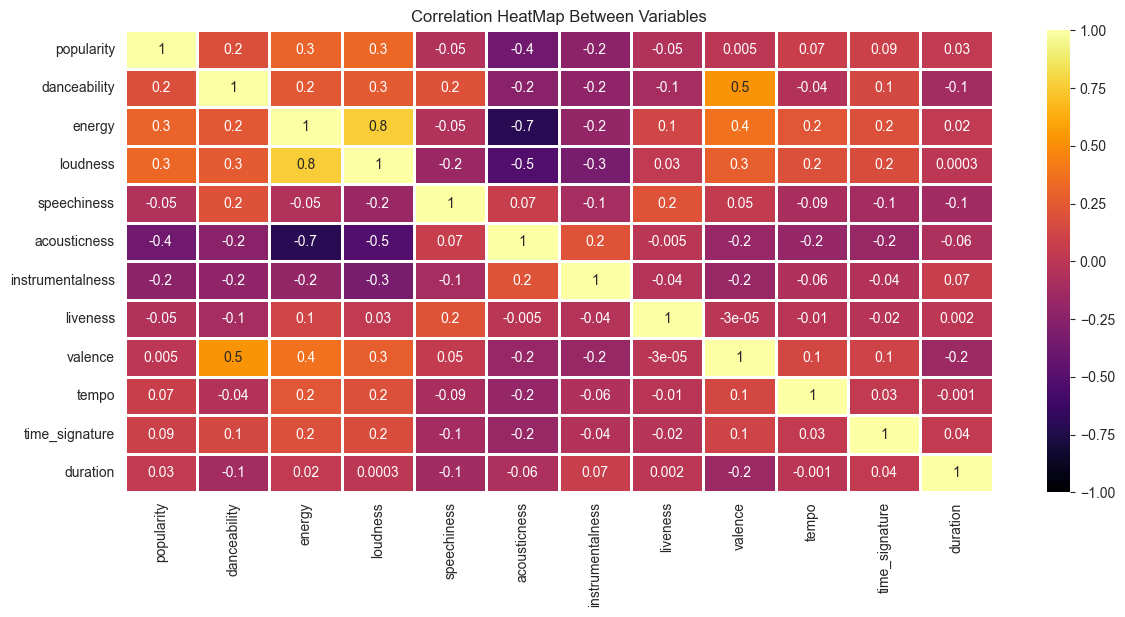

In [35]:
# Drop categorical columns and calculate Pearson correlation matrix
corr_df = df_tracks.drop(["key", "mode", "explicit"], axis=1).corr(method="pearson", numeric_only=True)

# Set the figure size (width=14, height=6)
plt.figure(figsize=(14, 6))

# Plot the heatmap (annot=True shows numbers, cmap="inferno" sets the color theme)
heatmap = sns.heatmap(corr_df, annot=True, fmt=".1g", vmin=-1, vmax=1, center=0, cmap="inferno", linewidths=1)

# Set the title for the chart
heatmap.set_title("Correlation HeatMap Between Variables")

# Rotate X-axis labels by 90 degrees so they don't overlap
heatmap.set_xticklabels(heatmap.get_xticklabels(), rotation=90)

In [36]:
# Create a random sample comprising 0.4% of the total dataset.
# This prevents lag and overplotting when rendering complex scatter plots.
sample_df = df_tracks.sample(int(0.004 * len(df_tracks)))

In [37]:
print(len(sample_df))

2346


[Text(0.5, 1.0, 'Loudness vs Energy Correlation')]

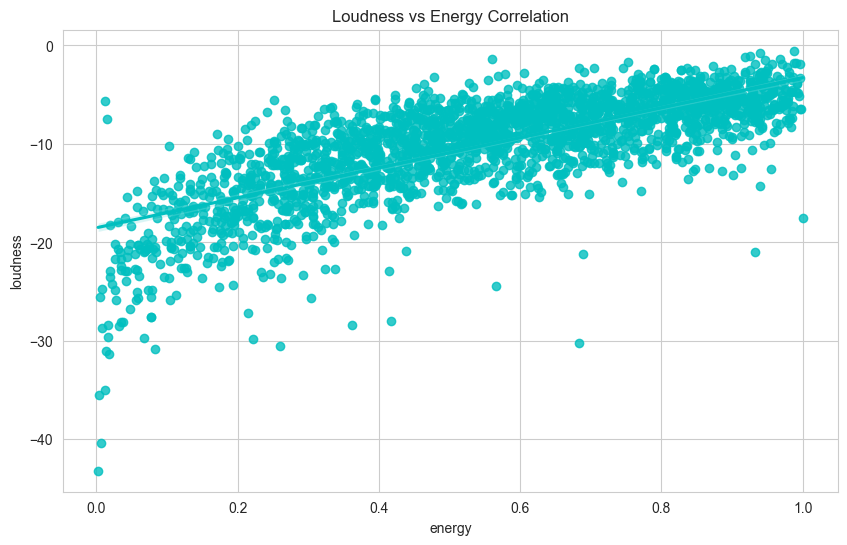

In [38]:
plt.figure(figsize=(10,6))

# Regression Plot
sns.regplot(data = sample_df, y = "loudness", x = "energy", color = "c").set(title = "Loudness vs Energy Correlation")

[Text(0.5, 1.0, 'Popularity vs Acousticness Correlation')]

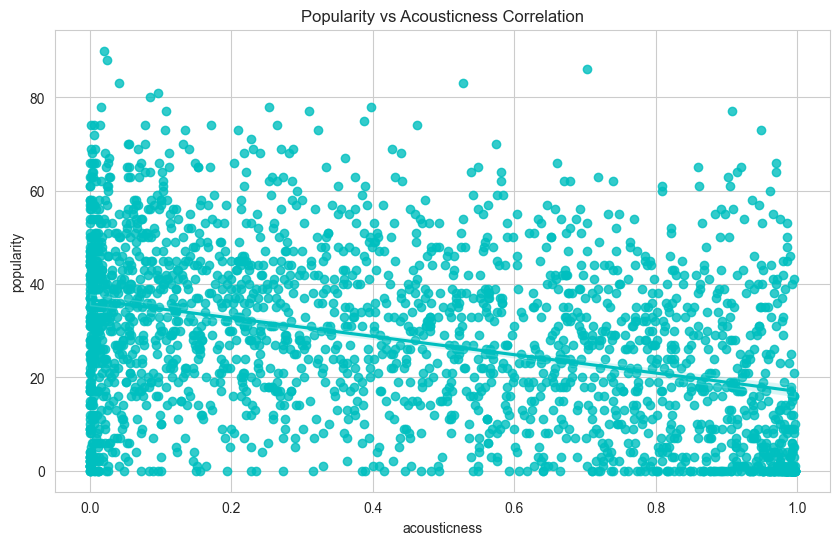

In [39]:
plt.figure(figsize=(10,6))

# Regression Plot
sns.regplot(data = sample_df, y = "popularity", x = "acousticness", color = "c").set(title = "Popularity vs Acousticness Correlation")

In [40]:
# Extract 'release_date' from the index and create a new column named 'dates'
df_tracks['dates'] = df_tracks.index.get_level_values('release_date')

# Ensure the new 'dates' column is in the proper datetime format
df_tracks.dates = pd.to_datetime(df_tracks.dates)

# Extract only the year (e.g., 1922, 2020) using the .dt accessor
years = df_tracks.dates.dt.year

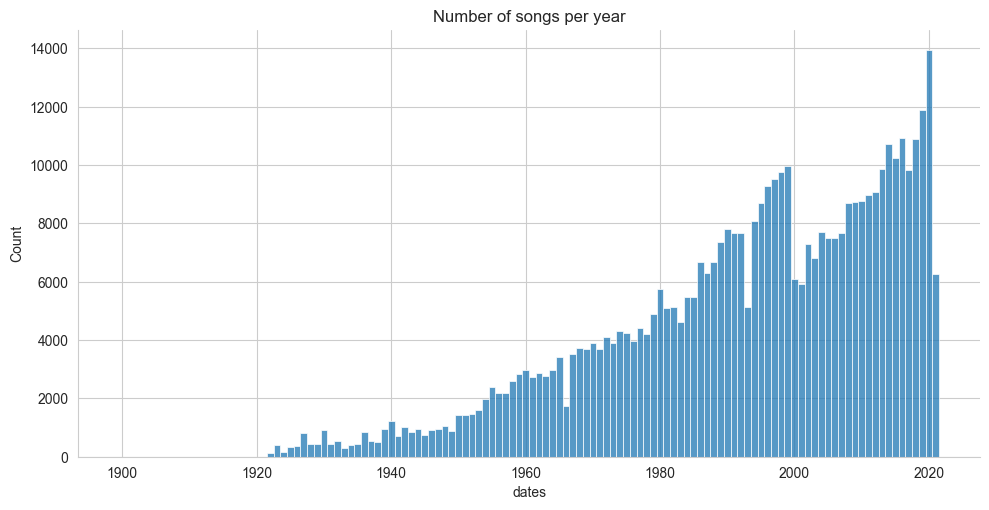

In [41]:
sns.displot(years, discrete=True, aspect=2, height=5, kind="hist").set(title="Number of songs per year")

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50,
  51,
  52,
  53,
  54,
  55,
  56,
  57,
  58,
  59,
  60,
  61,
  62,
  63,
  64,
  65,
  66,
  67,
  68,
  69,
  70,
  71,
  72,
  73,
  74,
  75,
  76,
  77,
  78,
  79,
  80,
  81,
  82,
  83,
  84,
  85,
  86,
  87,
  88,
  89,
  90,
  91,
  92,
  93,
  94,
  95,
  96,
  97,
  98,
  99,
  100],
 [Text(0, 0, '1900.0'),
  Text(1, 0, '1922.0'),
  Text(2, 0, '1923.0'),
  Text(3, 0, '1924.0'),
  Text(4, 0, '1925.0'),
  Text(5, 0, '1926.0'),
  Text(6, 0, '1927.0'),
  Text(7, 0, '1928.0'),
  Text(8, 0, '1929.0'),
  Text(9, 0, '1930.0'),
  Text(10, 0, '1931.0'),
  Text(11, 0, '1932.0'),
  Text(12, 0, '1933.0'),
  Text(13, 0, '1934.0'),
  Text(14, 0, '1935.0'),
  Text(15, 0, '1936.0'),
  Text(16, 0

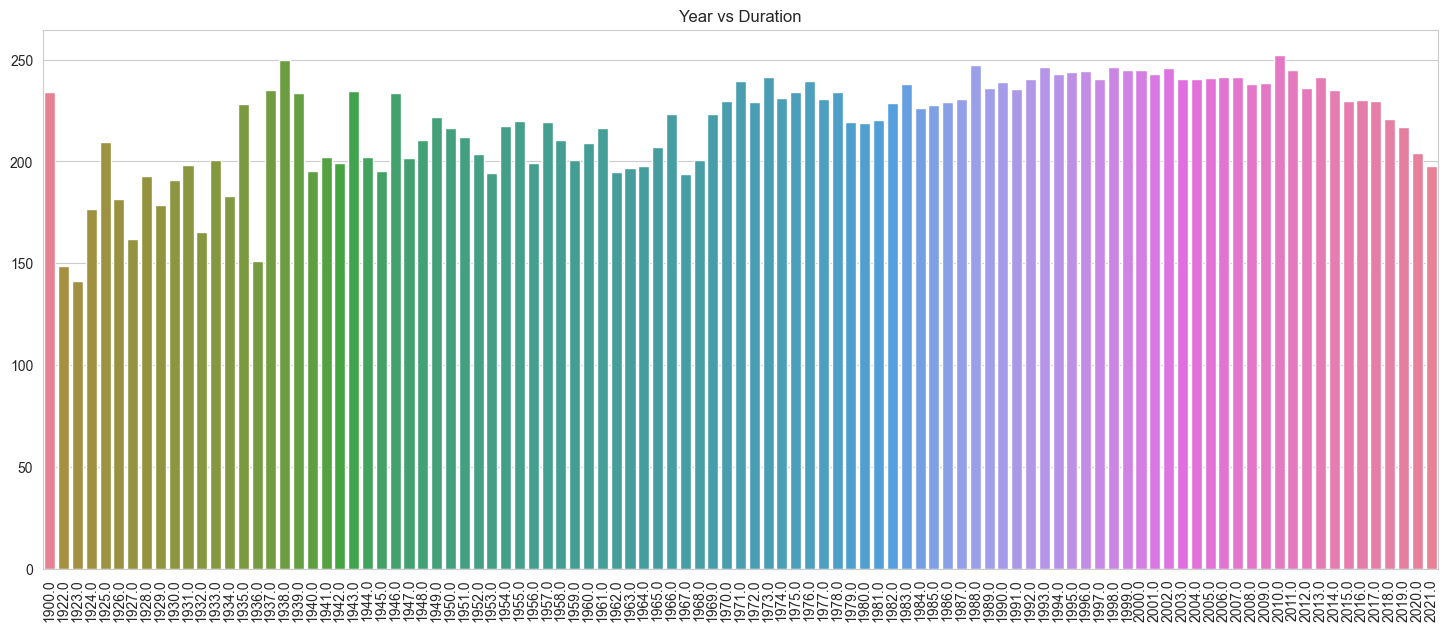

In [42]:
total_dr = df_tracks.duration
fig_dims = (18, 7)
fig, ax = plt.subplots(figsize=fig_dims)

# SỬA LỖI TẠI ĐÂY: Thêm .values, đổi errwidth thành errorbar
# VÀ THÊM màu sắc (palette, hue, legend)
fig = sns.barplot(
    x=years.values,
    y=total_dr.values,
    ax=ax,
    errorbar=None,
    palette="husl",       # Thêm bảng màu cầu vồng
    hue=years.values,     # Chia màu theo từng năm
    legend=False          # Tắt bảng chú thích màu
).set(title="Year vs Duration")

plt.xticks(rotation=90)

(array([1880., 1900., 1920., 1940., 1960., 1980., 2000., 2020., 2040.]),
 [Text(1880.0, 0, '1880'),
  Text(1900.0, 0, '1900'),
  Text(1920.0, 0, '1920'),
  Text(1940.0, 0, '1940'),
  Text(1960.0, 0, '1960'),
  Text(1980.0, 0, '1980'),
  Text(2000.0, 0, '2000'),
  Text(2020.0, 0, '2020'),
  Text(2040.0, 0, '2040')])

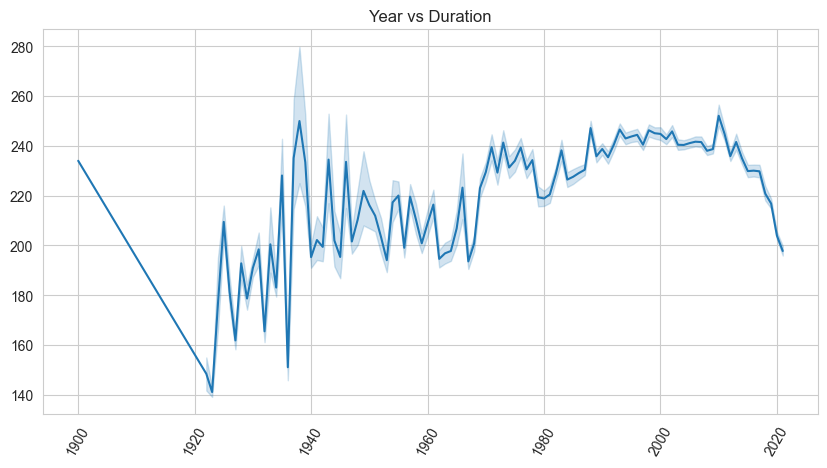

In [43]:
# Extract the duration column
total_dr = df_tracks.duration

# Set the background style to have a white grid for easier reading
sns.set_style(style="whitegrid")

# Set the dimensions for the figure (width 10, height 5)
fig_dims = (10, 5)
fig, ax = plt.subplots(figsize=fig_dims)

# Create a line plot to show the trend of song duration over the years
# Tip: Using .values prevents duplicate index errors in newer Pandas versions
fig = sns.lineplot(x=years.values, y=total_dr.values, ax=ax).set(title="Year vs Duration")

# Rotate the x-axis labels (years) by 60 degrees to prevent overlapping
plt.xticks(rotation=60)

In [44]:
df_genre = pd.read_csv('data/SpotifyFeatures.csv')
df_genre.head()

,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,Movie,Henri Salvador,C'est beau de faire un Show,0BRjO6ga9RKCKjfDqeFgWV,0,0.611,0.389,99373,0.910,0.000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814
1,Movie,Martin & les fées,Perdu d'avance (par Gad Elmaleh),0BjC1NfoEOOusryehmNudP,1,0.246,0.590,137373,0.737,0.000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816
2,Movie,Joseph Williams,Don't Let Me Be Lonely Tonight,0CoSDzoNIKCRs124s9uTVy,3,0.952,0.663,170267,0.131,0.000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368
3,Movie,Henri Salvador,Dis-moi Monsieur Gordon Cooper,0Gc6TVm52BwZD07Ki6tIvf,0,0.703,0.240,152427,0.326,0.000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227
4,Movie,Fabien Nataf,Ouverture,0IuslXpMROHdEPvSl1fTQK,4,0.950,0.331,82625,0.225,0.123,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390


C:\Users\PC\AppData\Local\Temp\ipykernel_25256\3174694436.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y='genre', x='duration_ms', data=df_genre, palette="rocket")


Text(0, 0.5, 'Genres')

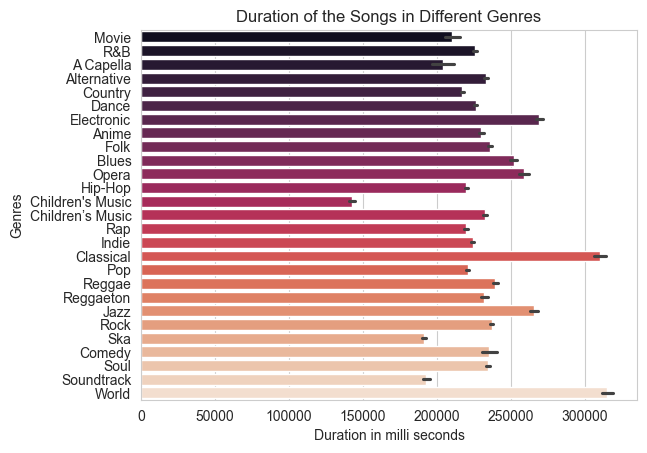

In [45]:
plt.title("Duration of the Songs in Different Genres")
sns.barplot(y='genre', x='duration_ms', data=df_genre, palette="rocket")
plt.xlabel("Duration in milli seconds")
plt.ylabel("Genres")

[Text(0.5, 1.0, 'Top 5 Genres by Popularity')]

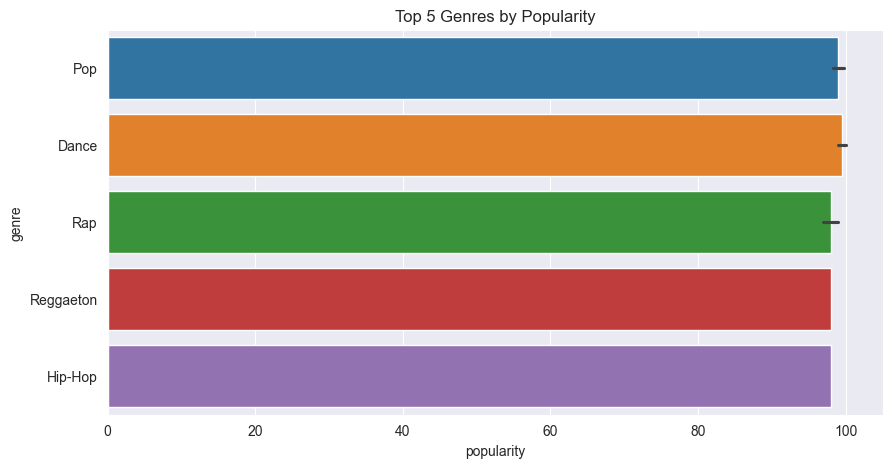

In [46]:
sns.set_style(style="darkgrid")
plt.figure(figsize=(10, 5))

famous = df_genre.sort_values("popularity", ascending=False).head(10)

sns.barplot(
    y='genre',
    x='popularity',
    data=famous,
    palette='tab10',
    hue='genre',
    legend=False
).set(title="Top 5 Genres by Popularity")